In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\sankeerth\Projects\BankChurners_Clean.csv")

In [6]:
sns.set_style("whitegrid")

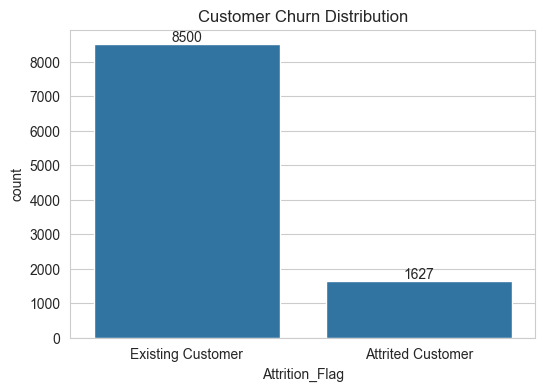

In [10]:
#how many customers are present and left the bank 
#Churn Distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x='Attrition_Flag'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")

plt.show()


In [11]:
#What is the churn rate of the customers left the bank?
Churn_rate = round(df['Churn'].mean()*100,2)
print("Churn_rate=",Churn_rate,"%")


Churn_rate= 16.07 %


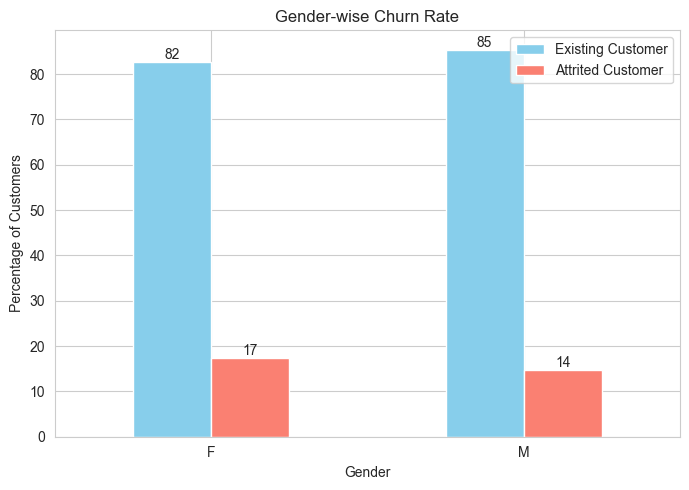

In [ ]:
#Churn by Gender (percentage)
gender_churn_rate = pd.crosstab(
    df['Gender'],
    df['Churn'],
    normalize='index'
) * 100

ax = gender_churn_rate.plot(
    kind='bar',
    figsize=(7,5),
    color=['skyblue', 'salmon']
)
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.title("Gender-wise Churn Rate")
plt.xlabel("Gender")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(['Existing Customer', 'Attrited Customer'])
plt.tight_layout()
plt.show()

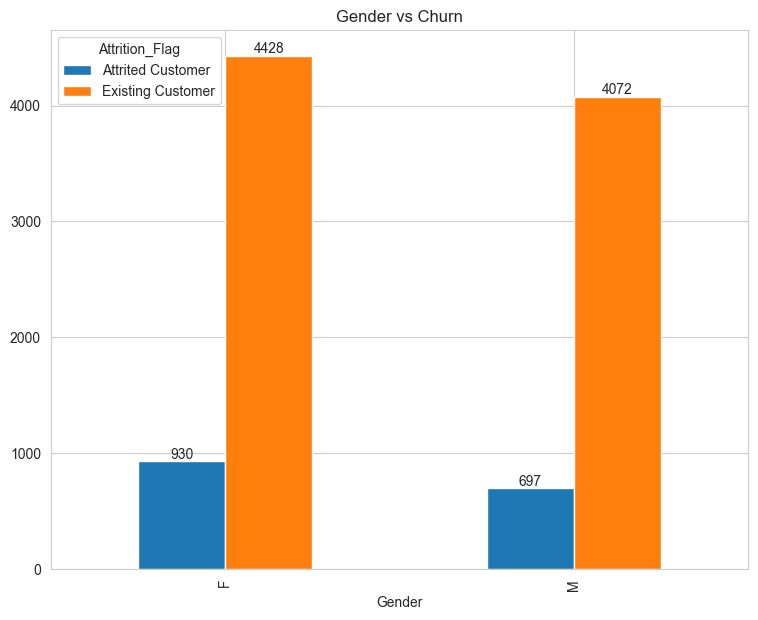

In [ ]:
#churn by gender(count)
gender_churn = pd.crosstab(
    df['Gender'],
    df['Attrition_Flag']
)

ax = gender_churn.plot(
    kind='bar',
    figsize=(9,7)
)
for container in ax.containers:
    ax.bar_label(container, fmt='%d') 

plt.title("Gender vs Churn")
plt.show()

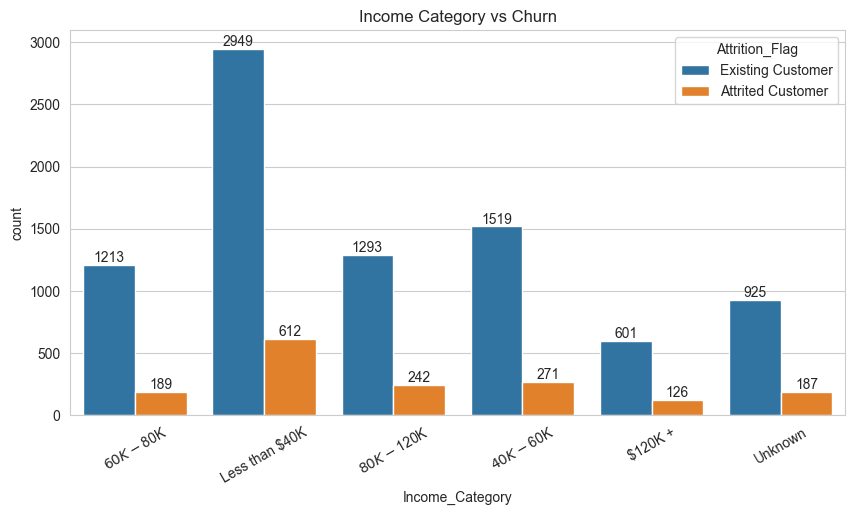

In [22]:
#which income category is churning more?
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x='Income_Category',
    hue='Attrition_Flag'
)
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=30)

plt.title("Income Category vs Churn")

plt.show()

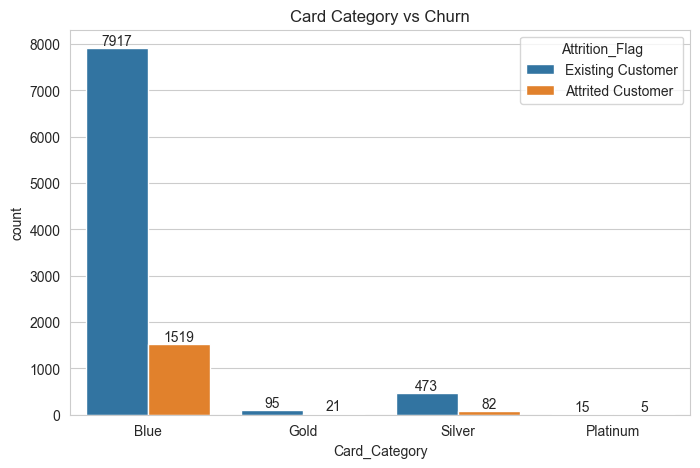

In [24]:
#which type of card holders are churning more?
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Card_Category',
    hue='Attrition_Flag'
)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Card Category vs Churn")

plt.show()

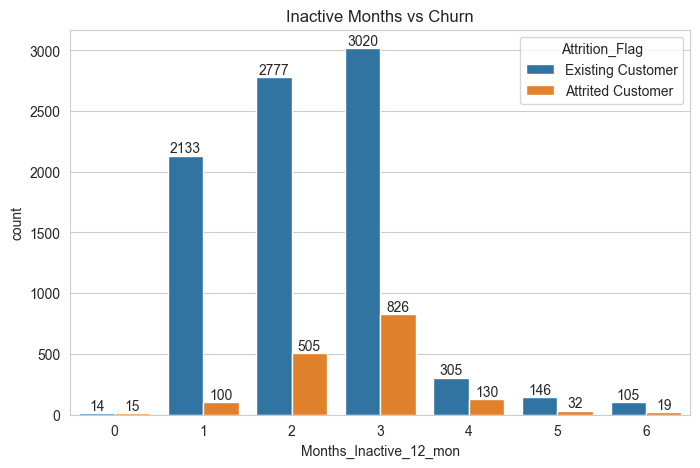

In [25]:
#Churn by number of inactive months
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Months_Inactive_12_mon',
    hue='Attrition_Flag'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Inactive Months vs Churn")

plt.show()

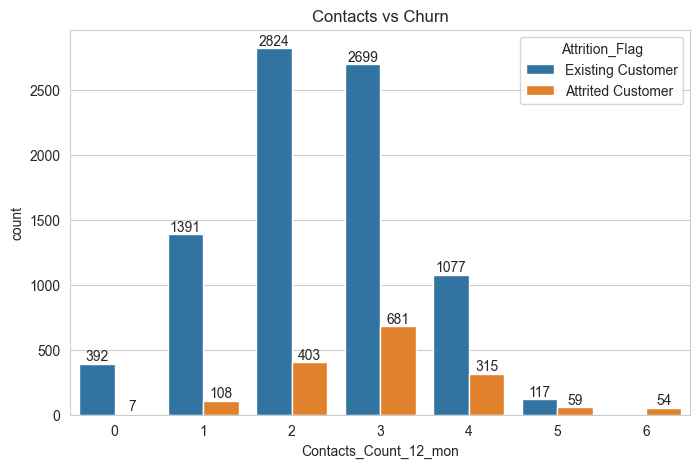

In [26]:
#churn by number of contacts made
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Contacts_Count_12_mon',
    hue='Attrition_Flag'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Contacts vs Churn")

plt.show()

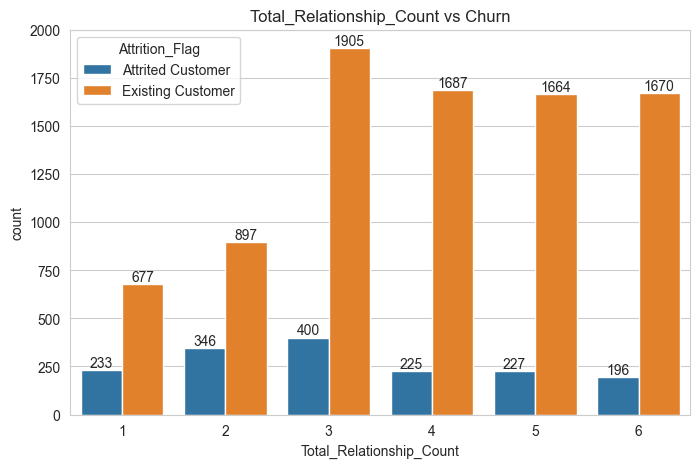

In [29]:
#churn by total_relationship count
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Total_Relationship_Count',
    hue='Attrition_Flag'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Total_Relationship_Count vs Churn")

plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_20504\3633404862.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = (df.groupby('Age_Group')['Churn']


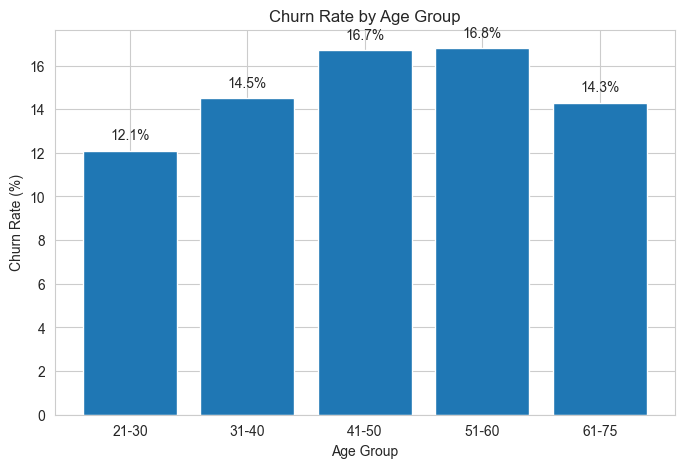

In [ ]:
#churn rate by age group
df['Age_Group'] = pd.cut(
    df['Customer_Age'],
    bins=[20,30,40,50,60,75],
    labels=['21-30','31-40','41-50','51-60','61-75']
)

# Calculate churn rate
age_churn = (df.groupby('Age_Group')['Churn']
               .mean()
               .mul(100)
               .round(1))

plt.figure(figsize=(8,5))
bars = plt.bar(age_churn.index.astype(str), age_churn.values)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

# Show values
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center'
    )

plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_20504\1766635935.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Age_Group')


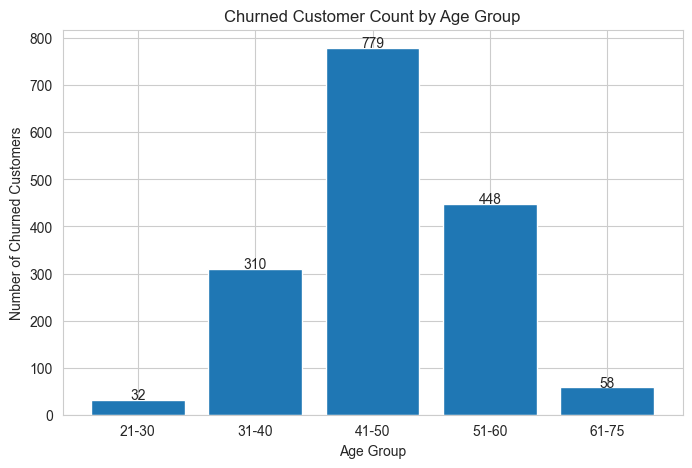

In [44]:
#churn by age group
df['Age_Group'] = pd.cut(
    df['Customer_Age'],
    bins=[20,30,40,50,60,75],
    labels=['21-30','31-40','41-50','51-60','61-75']
)

age_churn_count = (
    df[df['Churn'] == 1]
    .groupby('Age_Group')
    .size()
)

plt.figure(figsize=(8,5))
bars = plt.bar(age_churn_count.index.astype(str), age_churn_count.values)

plt.title("Churned Customer Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Churned Customers")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{int(bar.get_height())}',
        ha='center'
    )

plt.show()

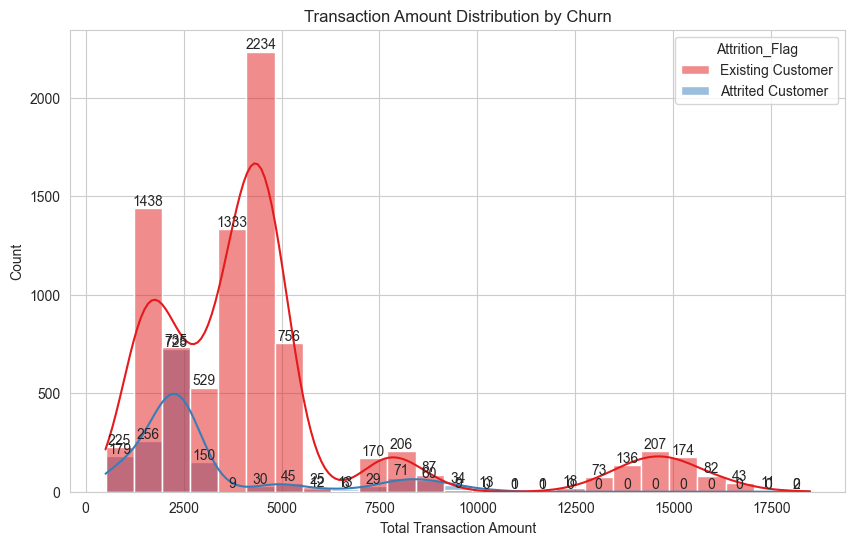

In [ ]:
#churn by trans amt
plt.figure(figsize=(10,6))

ax = sns.histplot(
    data=df,
    x='Total_Trans_Amt',
    hue='Attrition_Flag',
    bins=25,
    kde=True,
    palette='Set1'
)

for container in ax.containers:
    ax.bar_label(container)
    
plt.title("Transaction Amount Distribution by Churn")
plt.xlabel("Total Transaction Amount")
plt.ylabel("Count")
plt.show()

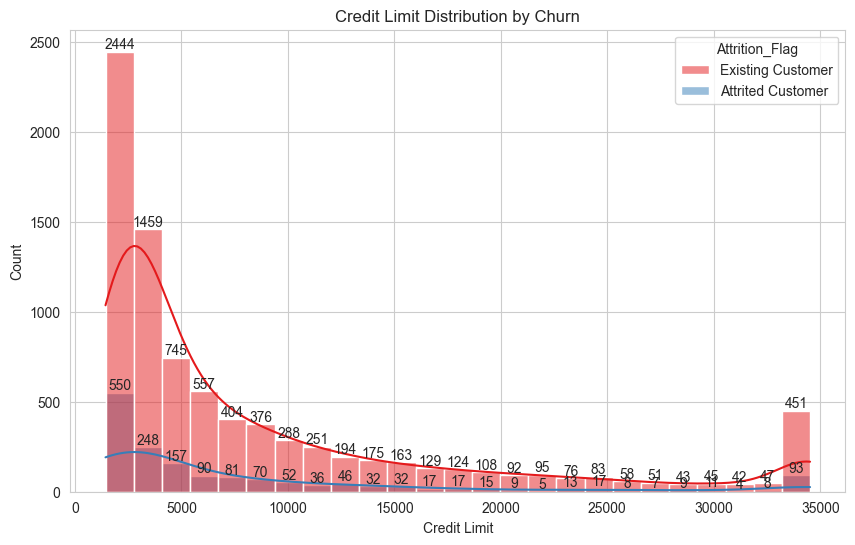

In [ ]:
#churn by credit limit
plt.figure(figsize=(10,6))

ax = sns.histplot(
    data=df,
    x='Credit_Limit',
    hue='Attrition_Flag',
    bins=25,
    kde=True,
    palette='Set1'
)

for container in ax.containers:
    ax.bar_label(container)
    
plt.title("Credit Limit Distribution by Churn")
plt.xlabel("Credit Limit")
plt.ylabel("Count")
plt.show()

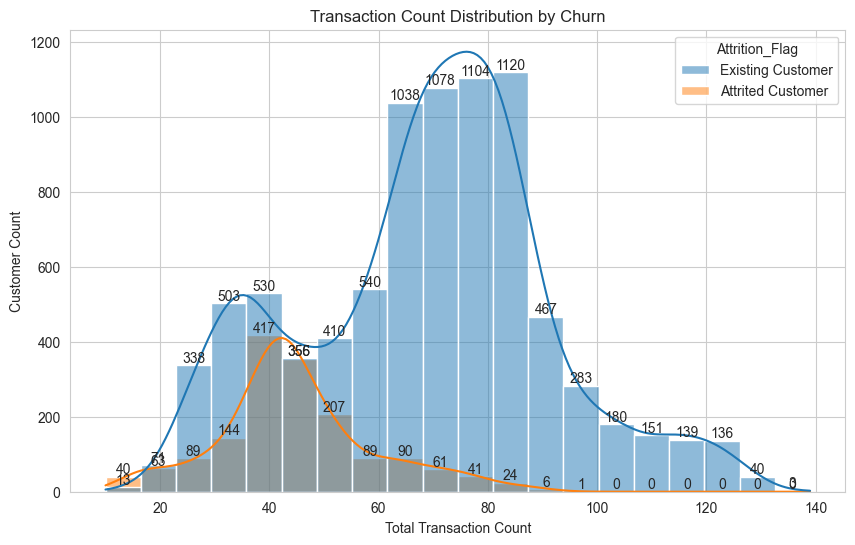

In [ ]:
#churn by trans cnt
plt.figure(figsize=(10,6))

ax = sns.histplot(
    data=df,
    x='Total_Trans_Ct',
    hue='Attrition_Flag',
    bins=20,
    kde=True,
    multiple='layer'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Transaction Count Distribution by Churn")
plt.xlabel("Total Transaction Count")
plt.ylabel("Customer Count")

plt.show()

In [62]:
#top risk customers
high_risk = df[
    (df['Months_Inactive_12_mon'] >= 3)
    &
    (df['Total_Trans_Ct'] < 45)
    &
    (df['Total_Relationship_Count'] <= 3)
]

high_risk.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn,Age_Group
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0,31-40
12,710599683,Existing Customer,56,M,1,College,Single,$80K - $120K,Blue,36,...,11751.0,0,11751.0,3.397,1539,17,3.250,0.000,0,51-60
21,708508758,Attrited Customer,62,F,0,Graduate,Married,Less than $40K,Blue,49,...,1438.3,0,1438.3,1.047,692,16,0.600,0.000,1,61-75
23,811604133,Existing Customer,47,F,4,Unknown,Single,Less than $40K,Blue,36,...,2492.0,1560,932.0,0.573,1126,23,0.353,0.626,0,41-50
27,804424383,Existing Customer,63,M,1,Unknown,Married,$60K - $80K,Blue,56,...,10215.0,1010,9205.0,0.843,1904,40,1.000,0.099,0,61-75


In [63]:
high_risk.to_csv(
    "High_Risk_Customers.csv",
    index=False
)

In [64]:
import os
print(os.getcwd())

c:\Users\Admin\AppData\Local\Programs\Microsoft VS Code
